<img src="./images/HUJI logo.jpeg" alt="HUJI" width="400">
<img src="./images/EHRI logo.png" alt="EHRI" width="400">

# EHRI - Technical Workshop
## Using LLMs for Distant Reading of Holocaust Testimonies

Itamar Trainin      -	  itamar.trainin@mail.huji.ac.il \
Renana Keydar		-	  renana.keydar@mail.huji.ac.il	 \
Amit Pinchevski 	-     amitpi@mail.huji.ac.il



In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

tqdm.pandas()

***

# Using LLMs with Python

## LLM Frameworks

<img src="./images/LLM Frameworks.png" alt="pipeline" width="1000">

https://github.com/BerriAI/litellm

## Importing LiteLLM

In [2]:
# Install litellm package
!pip install litellm

In [3]:
# We will be working with the "completion" endpoint
from litellm import completion

## Setting Provider Key

```
import os 
os.environ["OPENAI_API_KEY"] = "your-openai-key" 
os.environ["ANTHROPIC_API_KEY"] = "your-openai-key"
```

## Querying an LLM

chat/completion function definition: https://docs.litellm.ai/docs/completion/input

In [4]:
# Creating a quety to gpt-5
response = completion(
    model="gpt-5",
    messages=[
        {
            "role": "user", 
            "content": "Please tell me a joke."
        }
    ],
    temperature=1,
    max_tokens=None,
    n=1
)

print(response)

ModelResponse(id='chatcmpl-CSgiB4LushbZrpMnIGJVuDZsxXEqr', created=1760953403, model='gpt-5-2025-08-07', object='chat.completion', system_fingerprint=None, choices=[Choices(finish_reason='stop', index=0, message=Message(content='I ordered a chicken and an egg from Amazon. I’ll let you know which comes first.', role='assistant', tool_calls=None, function_call=None, provider_specific_fields={'refusal': None}, annotations=[]), provider_specific_fields={})], usage=Usage(completion_tokens=220, prompt_tokens=12, total_tokens=232, completion_tokens_details=CompletionTokensDetailsWrapper(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=192, rejected_prediction_tokens=0, text_tokens=None), prompt_tokens_details=PromptTokensDetailsWrapper(audio_tokens=0, cached_tokens=0, text_tokens=None, image_tokens=None)), service_tier='default')


### Output Format
docs: https://docs.litellm.ai/docs/completion/output

In [5]:
resp_content = response['choices'][0]['message']['content']

print(resp_content)

I ordered a chicken and an egg from Amazon. I’ll let you know which comes first.


***

# Reading the Testimonies

In [6]:
import oral_interview_utils

### Exploration

In [7]:
testimonies_dir = './testimonies'

In [8]:
# print the testimony files in the folder
files_in_dir = os.listdir(testimonies_dir)
print(files_in_dir)

['38961.txt', '24622.txt', '40991.txt', '38963.txt', '47180.txt', '24625.txt', '45152.txt', '24587.txt', '22530.txt', '22608.txt', '38929.txt', '36938.txt', '22582.txt', '22586.txt', '41035.txt', '22579.txt', '30753.txt', '43019.txt', '45091.txt', '24651.txt', '20580.txt', '45132.txt', '30751.txt', '20581.txt', '24650.txt', '32783.txt', '36917.txt', '34857.txt', '22600.txt', '20566.txt', '38936.txt', '32809.txt', '26672.txt', '26699.txt', '45064.txt', '32788.txt', '32777.txt', '30772.txt', '20575.txt', '22598.txt', '30765.txt', '43060.txt', '20505.txt', '38996.txt', '24615.txt', '24614.txt', '28748.txt', '28758.txt', '22538.txt', '38987.txt']


In [9]:
print(f'Total available testimonies: {len(files_in_dir)}')

Total available testimonies: 50


In [10]:
# print the content of a single testimony
with open('./testimonies/38961.txt', 'r', encoding='utf-8') as f:
    print(f.read())

INT: Today is January the 28th, 1998. This is an interview with survivor Shlomo Barnea, whose name at birth was Berkowitch. The interviewer is Joanna Buchan-- B-U-C-H-A-N. And the interview is taking place in London in the UK. The language of the interview will be English. This is an interview with survivor Mr. Shlomo Barnea-- B-A-R-N-E-A-- whose name at birth was Berkowitch-- B-E-R-K-- O--W-I-T-C-H. The interviewer is myself, Joanna Buchan, B-U-C-H-A-N. The interview is taking place in London on the 28th of January 1998. And the interview will be in English. Mr. Barnea, first of all, could you just say your name on tape for me and how you spell it? SB: Yes, my name is Shlomo-- S-H-L-O-M-O-- Barnea-- B-A-R-N-E-A.  INT: And what was your name during the war? SB: It was entirely different. It was Daniel Berkowitch-- B-E-R-K-O-W-I-T-S-- T-C-H.  INT: And where were you born, Mr. Barnea? SB: I was born actually in a place very near Budapest, what's called Újpest. And today it is a part of B

### Load Testimonies to DataFrame

In [11]:
# Read the testimonies into a DataFrame
testimonies = oral_interview_utils.get_testimonies(testimonies_dir)

testimonies.head()

,testimony_id,content
0,38961,"INT: Today is January the 28th, 1998. This is ..."
1,24622,"INT: Today's date is January 10, 1997. Survivo..."
2,40991,"INT: March 19, 1998. The survivor is Mr. Egon ..."
3,38963,INT: Service-- is that right? RS: [LAUGHS] IN...
4,47180,INT: Hello. My name is Fran Simon. Today I hav...


In [12]:
print(f'Number of loaded testimonies: {len(testimonies)}')

Number of loaded testimonies: 50


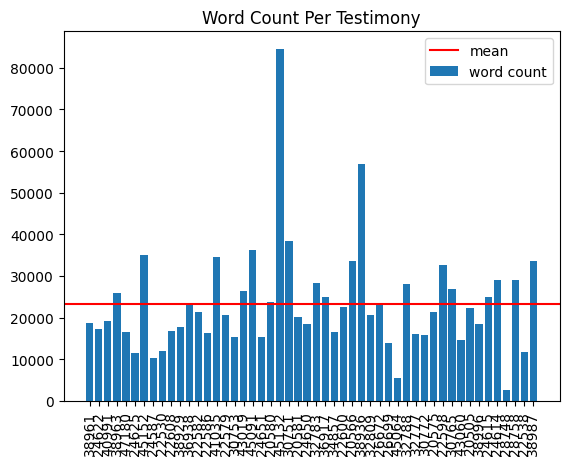

In [13]:
# Mean side of the testimonies
mean_word_count = testimonies['content'].apply(lambda x: len(x.split(' ')))

plt.bar(testimonies['testimony_id'], mean_word_count, label='word count')
plt.axhline(mean_word_count.mean(), color='red', label='mean')
plt.xticks(rotation=90)
plt.title('Word Count Per Testimony')
plt.legend()
plt.show()

***

# Segmentation

In [14]:
import segmentation

### Speaker Sides Segmentation

<img src="./images/speakers_segmentation.png" alt="Speakers Sides Segmentation Example" width="400">

In [15]:
testimonies = segmentation.segment_speakers(testimonies)

testimonies.head()

,testimony_id,speakers_segment,speaker,line
0,38961,0,INT,"Today is January the 28th, 1998. This is an in..."
1,38961,1,SB,"Yes, my name is Shlomo-- S-H-L-O-M-O-- Barnea-..."
2,38961,2,INT,And what was your name during the war?
3,38961,3,SB,It was entirely different. It was Daniel Berko...
4,38961,4,INT,"And where were you born, Mr. Barnea?"


### Micro Segmentation

<img src="./images/micro_segmentation.png" alt="Micro-Segmentation Example" width="400">

In [16]:
testimonies['micro_segment'] = segmentation.segment_micro_testimonies(testimonies, min_words=10)

testimonies.head(10)

,testimony_id,speakers_segment,speaker,line,micro_segment
0,38961,0,INT,"Today is January the 28th, 1998. This is an in...",0
1,38961,1,SB,"Yes, my name is Shlomo-- S-H-L-O-M-O-- Barnea-...",0
2,38961,2,INT,And what was your name during the war?,1
3,38961,3,SB,It was entirely different. It was Daniel Berko...,1
4,38961,4,INT,"And where were you born, Mr. Barnea?",2
5,38961,5,SB,I was born actually in a place very near Budap...,2
6,38961,6,INT,And that's in Hungary.,3
7,38961,7,SB,"In Hungary, of course.",3
8,38961,8,INT,And when were you born? What's your date of bi...,3
9,38961,9,SB,"15th of January, 1933.",3


***

# Question Type Classification 

## Guidelines for Prompting:

<img src="./images/classification.png" alt="classification" width="800">

In [17]:
def get_type(speaker_line, model_name='gpt-5'):
    prompt = f"""
    You are a Holocaust researcher analyzing survivor testimonies.
    The testimonies are transcripts of an oral interviews.
    The interviews is composed of speaker sides -- the interviewer questions and
    the survivor answers. 
    A prefix of "INT" identifies an "interviewer" line.
    A prefix of "<initials>" identifies a suviror line.
    You will be given one question asked by an interviewer during a conversation 
    with a Holocaust survivor.

    Your task is to classify the question into exactly **one** of the following 
    types, based on its structure and intent:

    Question Types:
    1. How Question – Asks about a method, process, or manner 
    2. What Question – Asks for information, descriptions, or clarifications 
    3. When Question – Asks about time or timing 
    4. Where Question – Asks about a place or location 
    5. Why Question – Asks about cause, motivation, or reason 
    6. Who Question – Asks about a person or group 
    7. Other Question – Does not match any of the categories above or is ambiguous.

    Then, write a brief explanation (no more than one sentence) explaining why you 
    selected that type.

    Do not return more than one type.

    ### Output JSON format:
    {{
        "type": "<one of the 7 types above>",
        "explanation": "<one-sentence explanation>"
    }}
        
    ### Input:
    Interviewer Question: "{speaker_line}"
    """

    try:
        response = completion(
            model=model_name,
            messages=[
                {
                    "role": "user", 
                    "content": prompt
                }
            ],
            temperature=1,
            max_tokens=None,
            n=1
        )
    
        output = oral_interview_utils.extract_json(response['choices'][0]['message']['content'])
        
        return output['type'], output['explanation']
    except Exception as e:
        print(e)
        return None, None

In [18]:
# Filter non questions
questions = testimonies[testimonies['speaker'] == 'INT']
questions = questions[:10] # Small Sample to run faster.

questions

,testimony_id,speakers_segment,speaker,line,micro_segment
0,38961,0,INT,"Today is January the 28th, 1998. This is an in...",0
2,38961,2,INT,And what was your name during the war?,1
4,38961,4,INT,"And where were you born, Mr. Barnea?",2
6,38961,6,INT,And that's in Hungary.,3
8,38961,8,INT,And when were you born? What's your date of bi...,3
10,38961,10,INT,And how old are you today?,4
12,38961,12,INT,"We start with your family, Mr. Berkowitch, wit...",5
14,38961,14,INT,And what did he do for a living? What was his ...,6
16,38961,16,INT,What do you think of-- do you-- what do you re...,7
18,38961,18,INT,"What kind of man was he then, would you say?",8


In [19]:
# Classify question types
question_types = questions['line'].progress_apply(get_type)
question_types = pd.DataFrame(question_types.tolist(), columns=['type', 'explanation'])


00%|███████████████████████████████████████████| 10/10 [00:39<00:00,  3.91s/it]

In [20]:
question_types

,type,explanation
0,How Question,It explicitly asks for how his name is spelled...
1,What Question,It asks for specific information—the survivor'...
2,Where Question,It asks for the location of Mr. Barnea's birth.
3,Where Question,It seeks to confirm the location by asking if ...
4,When Question,It asks for the time/date of the survivor's bi...
5,How Question,It asks 'how old' to elicit the survivor’s cur...
6,Who Question,It asks for the identity of a person (the fath...
7,What Question,It seeks information describing the person’s o...
8,What Question,It asks the survivor to describe what they rem...
9,What Question,It asks for a description of the man's charact...


***

 # Extracting Common Topics

## Previously used Topic Modeling Techniques

<img src="./images/lda.png" alt="pipeline" width="1000">

Ifergan, M., Abend, O., Keydar, R., & Pinchevski, A. (2024).
Identifying Narrative Patterns and Outliers in Holocaust Testimonies Using Topic Modeling.
In Proceedings of the First Workshop on Holocaust Testimonies as Language Resources (HTRes) @ LREC-COLING 2024 (pp. 44–52).

## Our Approach

<img src="./images/extraction_pipline.png" alt="pipeline" width="1000">

```
num_segments = 15
num_common_topics = 3
```

### Step 1: Extract LLM-Topic from each Micro-Segment

```
qa_topics = (
    testimonies
    .groupby(['testimony_id', 'micro_segment'])
    .progress_apply(
        lambda lines: get_single_topic(
            oral_interview_utils.join_speaker_lines(lines),
            model_name=model_name
        )
    )
    .reset_index()
    .rename(columns={0: 'topic'})
)
```

### Step 2: Macro Segment

<img src="./images/storyline.png" alt="storyline" width="800">

```
qa_topics['micro_macro_segment'] = (
    qa_topics
    .groupby('testimony_id', group_keys=False)['micro_segment']
    .apply(lambda g: pd.Series(segmentation.segment_macro(g, num_segments), index=g.index), include_groups=False)
)
```

## Step 3: Map-Reduce micro-topics to macro-topics

<img src="./images/map_reduce.png" alt="storyline" width="800">

```
common_topics = pd.DataFrame(
    qa_topics
    .groupby(['micro_macro_segment'])['topic']
    .progress_apply(lambda x: get_common_topics(x, num_common_topics))
    .tolist()
)
```

# Final Result 
## SF ; 15 Segments ; 3 Topics per Segment

<img src="./images/topics_sf.png" alt="topics" width="1000">